In [1]:
# Install newsapi
import subprocess
subprocess.run(['pip', 'install', 'newsapi-python', 'textblob'], capture_output=True)
print("Libraries installed!")

Libraries installed!


In [2]:
# Step 27: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import requests
import json
from datetime import datetime, timedelta

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
# Step 29: Fetch cricket news headlines
API_KEY = "450e679f41844bb596c45970c6f99ec1"

url = ('https://newsapi.org/v2/everything?'
       'q=IPL+cricket&'
       'language=en&'
       'sortBy=publishedAt&'
       'pageSize=100&'
       f'apiKey={API_KEY}')

response = requests.get(url)
news_data = response.json()

print("Status:", news_data['status'])
print("Total articles found:", news_data['totalResults'])

Status: ok
Total articles found: 449


In [4]:
# Step 30: Extract headlines into a dataframe
articles = news_data['articles']

news_list = []
for article in articles:
    news_list.append({
        'title': article['title'],
        'description': article['description'],
        'source': article['source']['name'],
        'published_at': article['publishedAt'],
        'url': article['url']
    })

news_df = pd.DataFrame(news_list)

# Clean - remove null titles
news_df = news_df.dropna(subset=['title'])

print("Total headlines extracted:", len(news_df))
print("\nSample headlines:")
print(news_df['title'].head(10))

Total headlines extracted: 99

Sample headlines:
0    Black Caps v England: Indian Premier League co...
1    Beyond the Boundary: AI, influencers rewrite t...
2    'There is a reason DC are at the bottom': Moha...
3         Stokes strikes after eight balls on comeback
4    ‘One game at a time’: KKR skipper Ajinkya Raha...
5    KSCA’s demand for tickets why IPL final was sh...
6    IPL 2026: RR vs. GT prediction, lineups, pitch...
7    Suryakumar Yadav and Devisha Shetty become par...
8    RR vs GT Dream11: Lineups, pitch report and sc...
9    DC vs KKR IPL 2026 live score, toss winner, wi...
Name: title, dtype: object


In [5]:
# Step 31: Sentiment Analysis on headlines
def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity
    
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity_score(text):
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity

# Apply to all headlines
news_df['sentiment'] = news_df['title'].apply(get_sentiment)
news_df['polarity_score'] = news_df['title'].apply(get_polarity_score)

print("✅ Sentiment analysis complete!")
print("\nSentiment Distribution:")
print(news_df['sentiment'].value_counts())

✅ Sentiment analysis complete!

Sentiment Distribution:
sentiment
Neutral     50
Positive    39
Negative    10
Name: count, dtype: int64


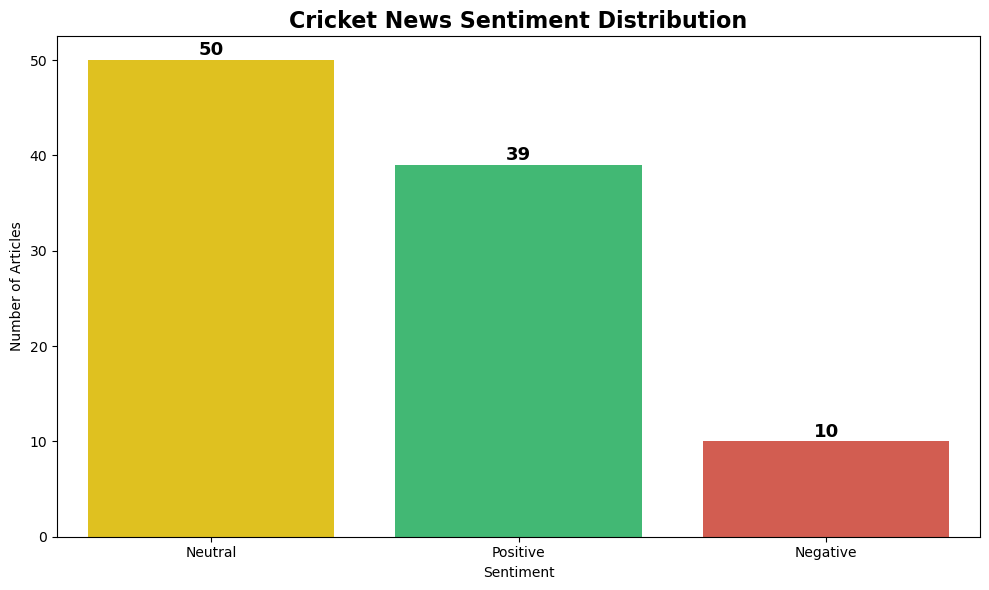

sentiment
Neutral     50
Positive    39
Negative    10
Name: count, dtype: int64


In [6]:
# Step 32: Visualize sentiment distribution
sentiment_counts = news_df['sentiment'].value_counts()

colors = ['#FFD700', '#2ECC71', '#E74C3C']

plt.figure(figsize=(10,6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            hue=sentiment_counts.index,
            palette={'Neutral': '#FFD700', 
                    'Positive': '#2ECC71', 
                    'Negative': '#E74C3C'},
            legend=False)

plt.title('Cricket News Sentiment Distribution', 
          fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', 
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\sentiment_distribution.png")
plt.show()

print(sentiment_counts)

In [7]:
# Step 33: Most positive and negative headlines
print("🟢 TOP 5 MOST POSITIVE HEADLINES:")
print("="*60)
top_positive = news_df.nlargest(5, 'polarity_score')[['title', 'polarity_score']]
for i, row in top_positive.iterrows():
    print(f"Score: {row['polarity_score']:.2f} | {row['title']}")

print("\n🔴 TOP 5 MOST NEGATIVE HEADLINES:")
print("="*60)
top_negative = news_df.nsmallest(5, 'polarity_score')[['title', 'polarity_score']]
for i, row in top_negative.iterrows():
    print(f"Score: {row['polarity_score']:.2f} | {row['title']}")

🟢 TOP 5 MOST POSITIVE HEADLINES:
Score: 0.80 | Hyderabad moves atop IPL with 33-run win over Punjab as Connolly's century goes in vain
Score: 0.68 | Which team has the best bowling economy rate in IPL 2026? Full rankings
Score: 0.60 | Are dropped catches costing PBKS? Shreyas Iyer's honest admission after SRH loss costs No. 1 spot in IPL 2026
Score: 0.54 | Dinesh Karthik on why he ranks RCB’s IPL win ‘right up there’ with 2007 T20 World Cup triumph
Score: 0.50 | Virat Kohli score in today's IPL 2026 match: How many runs did RCB star score against LSG at Ekana Stadium, Lucknow

🔴 TOP 5 MOST NEGATIVE HEADLINES:
Score: -0.88 | 'There is a reason DC are at the bottom': Mohammad Kaif's brutal verdict on Axar Patel's side in IPL 2026 standings
Score: -0.75 | 'Deeply Disappointed': Kal Somani group breaks silence after RR ownership deal fell through
Score: -0.50 | Bethell fails after injury scare in RCB defeat
Score: -0.50 | Sanju Samson refuses to be 'selfish' for 100 vs DC: Why the CSK star

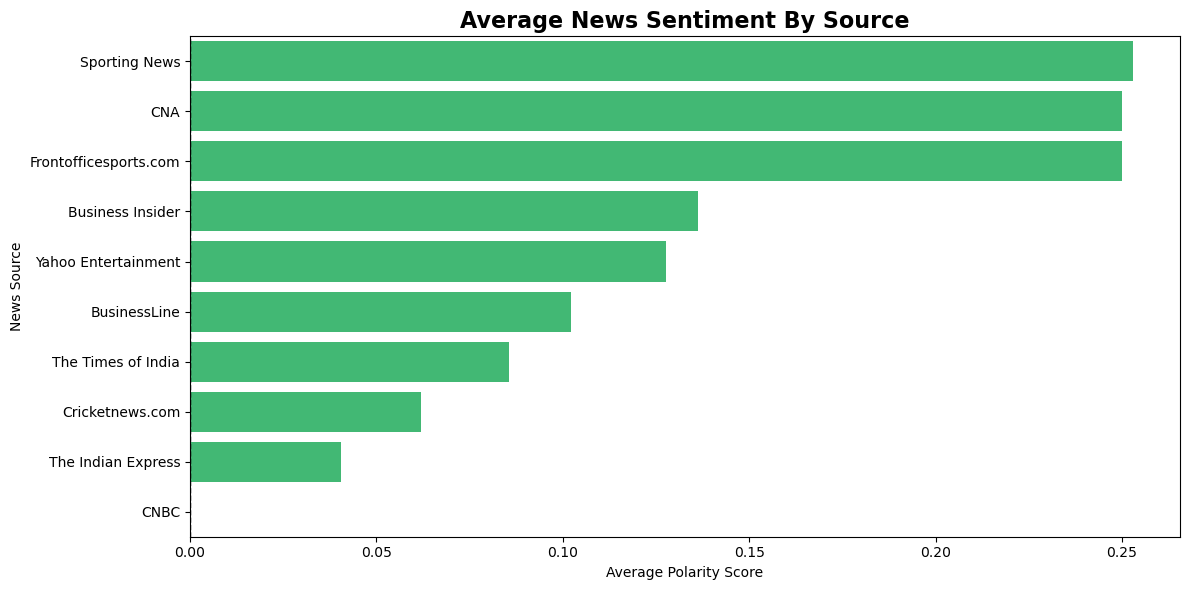

source
Sporting News            0.252893
CNA                      0.250000
Frontofficesports.com    0.250000
Business Insider         0.136364
Yahoo Entertainment      0.127778
BusinessLine             0.102083
The Times of India       0.085467
Cricketnews.com          0.062075
The Indian Express       0.040630
CNBC                     0.000000
Name: polarity_score, dtype: float64


In [8]:
# Step 34: Sentiment by news source
source_sentiment = news_df.groupby('source')['polarity_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in source_sentiment.values]

sns.barplot(x=source_sentiment.values, y=source_sentiment.index,
            hue=source_sentiment.index,
            palette=dict(zip(source_sentiment.index, colors)),
            legend=False)

plt.title('Average News Sentiment By Source',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Polarity Score')
plt.ylabel('News Source')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\sentiment_by_source.png")
plt.show()

print(source_sentiment)

In [9]:
# Step 35: Save news sentiment data
news_df.to_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\cricket_news_sentiment.csv", index=False)

print("✅ News sentiment data saved!")
print("\nFinal dataset shape:", news_df.shape)
print("\nColumns saved:", news_df.columns.tolist())

✅ News sentiment data saved!

Final dataset shape: (99, 7)

Columns saved: ['title', 'description', 'source', 'published_at', 'url', 'sentiment', 'polarity_score']
